<a href="https://colab.research.google.com/github/BumGyo/2026-1_CV/blob/main/2%EC%A3%BC%EC%B0%A8_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import Module

In [107]:
import cv2 as cv  # OpenCV를 사용하기 위해 cv2 import

import numpy as np   # 넘파이 사용
import matplotlib.pyplot as plt   # matplotlib : 시각화라이브러리

from google.colab.patches import cv2_imshow    # colab에서 cv.imshow 사용

HW#2-1

Fig3.9(a) 영상에 대해 오른쪽과 같은 결과가
나오도록 여러가지 경우에 대해 실험하고, 결과
를 분석해보세요.

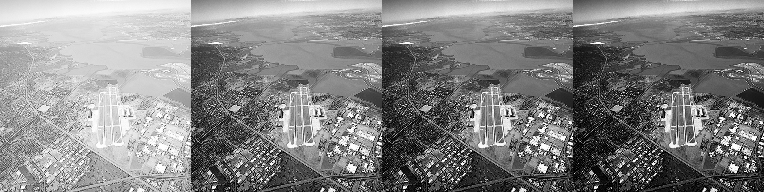

In [108]:
from google.colab.patches import cv2_imshow

img = cv.imread('/content/sample_data/Fig0309(a)(washed_out_aerial_image).tif')

img = cv.resize(img, dsize = (0,0), fx = 0.25, fy = 0.25)

def gamma(f, gamma = 1.0):
  f1 = f / 255.0                     # L=256이라고 가정, 픽셀을 0~1로 정규
  return np.uint8(255*(f1**gamma))   # 감마 보정 후 다시 0~255로 변환

gc = np.hstack((gamma(img, 1.0),gamma(img, 3.0),gamma(img, 4.0),gamma(img, 5.0)))
cv2_imshow(gc)

**결과분석**

s = cr^y

s = 출력 픽셀값, r = 입력 픽셀 값(0~1), y = 감마 값

Lecture2 강의자료의 8번에서 알 수 있듯이

위의 출력결과와 같이 감마의 값이 커질 수록 이미지가 더욱 어두워지는 것을 알 수 있음

이를 이용하여 사진의 선명도를 올릴 수 있다.

HW#2-2

Fig3.10(a) 영상에 대해 오른쪽과 같은 결과
가 나오도록 여러가지 경우에 대해 실험하고,
결과를 분석해보세요.


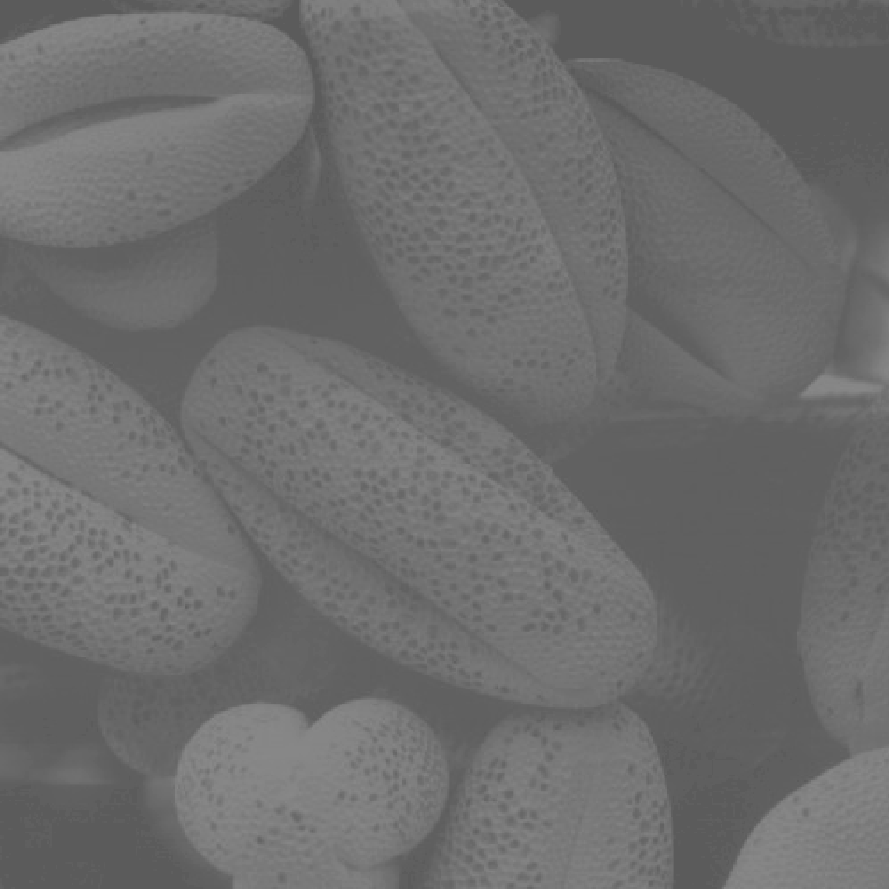

In [109]:
img = cv.imread('/content/sample_data/Fig0310(b)(washed_out_pollen_image).tif', cv.IMREAD_GRAYSCALE)
cv2_imshow(img)

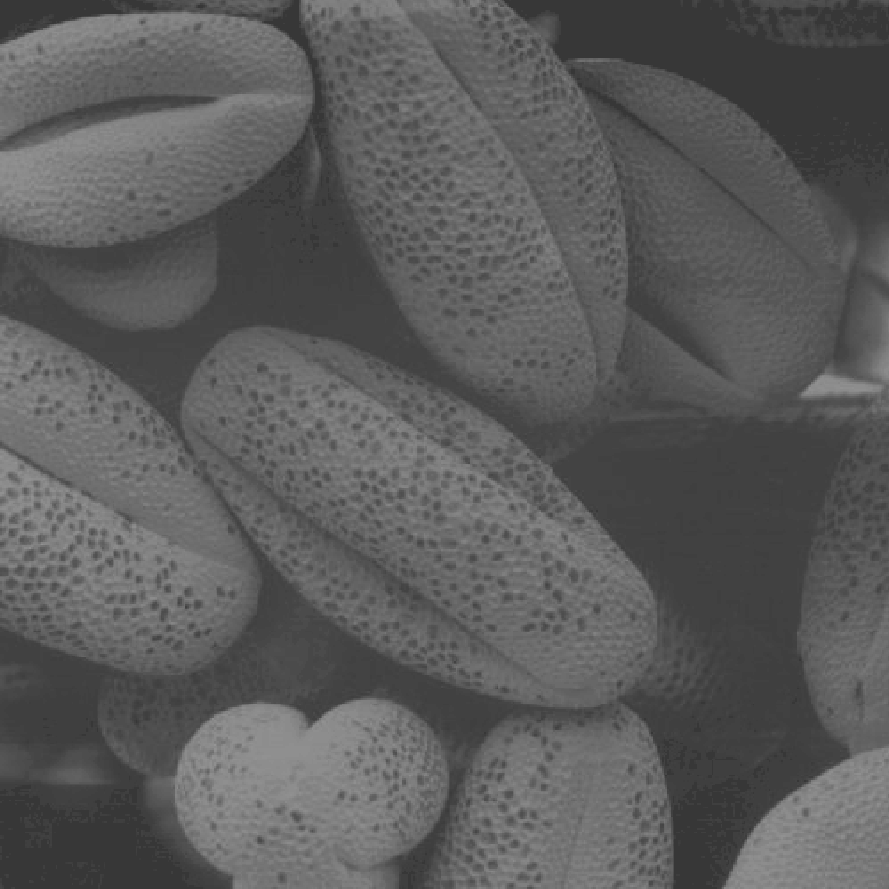

In [77]:
# 기준점 설정 (percent)
r1_p, s1_p = 30, 10
r2_p, s2_p = 70, 90

# 0~255로 변환
r1 = int(255 * (r1_p / 100.0))
s1 = int(255 * (s1_p / 100.0))
r2 = int(255 * (r2_p / 100.0))
s2 = int(255 * (s2_p / 100.0))

# mask 생성
mask = np.zeros(256, dtype="uint8")

for r in range(256):
    if r < r1:
        s = (s1 / r1) * r if r1 != 0 else 0
    elif r < r2:
        s = ((s2 - s1) / (r2 - r1)) * (r - r1) + s1 if r2 != r1 else s1
    else:
        s = ((255 - s2) / (255 - r2)) * (r - r2) + s2 if r2 != 255 else 255

    mask[r] = np.clip(s, 0, 255)

result = cv.LUT(img, mask)
cv2_imshow(result)

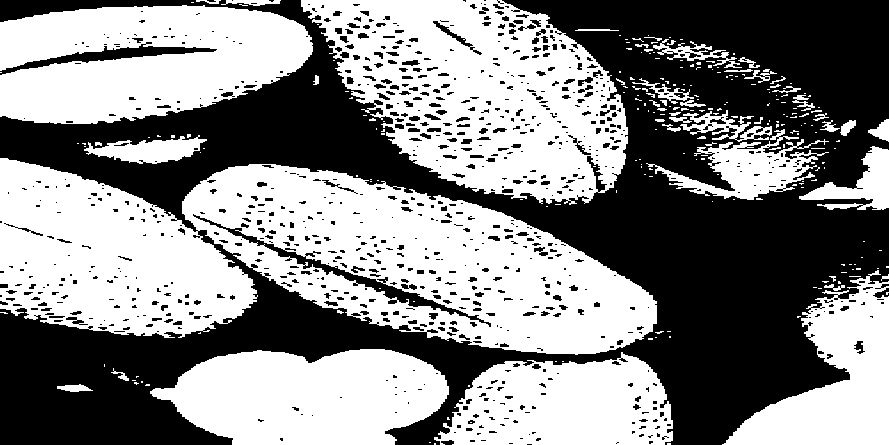

In [78]:
# Otsu 이진화
t_p = 41
T = int(255 * (t_p / 100.0))

mask = np.zeros(256, dtype="uint8")

for r in range(256):
    if r < T:
        s = 255 * 0.05
    else:
        s = 255 * 0.9
    mask[r] = s

result = cv.LUT(img, mask)

t, bin_img = cv.threshold(img[::2],0, 255, cv.THRESH_BINARY+cv.THRESH_OTSU)
cv2_imshow(bin_img)

**결과분석**

흐릿한 이미지를 Piecewise-Linear Transformation을 통해 전처리하며 대비가 뚜렷해지고 이미지가 선명해졌지만 Lecture2에서 소개된 Otsu 이진화 알고리즘을 이용한 thresholding을 적용한 경우는 대비는 뚜렷해졌지만 사라지는 정보가 많아서 아쉬웠다.

HW#2-3

임의의 영상을 입력 받아 아래와 같은 마스크를 사용하여 컨볼루션 하고, 그 결과를 분석해보세요.

In [79]:
img = cv.imread('/content/sample_data/lena.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

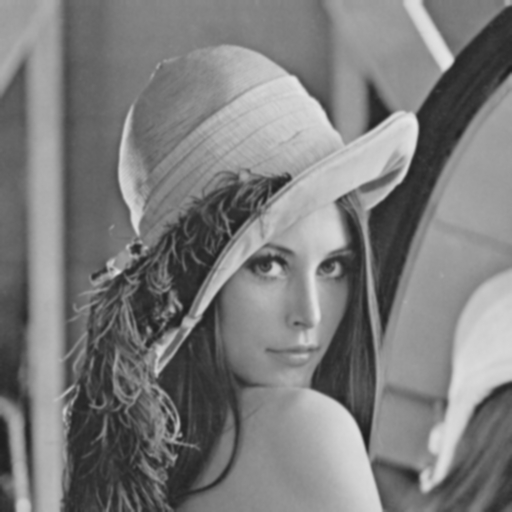

In [80]:
cv2_imshow(cv.GaussianBlur(gray,(5,5),0.0))

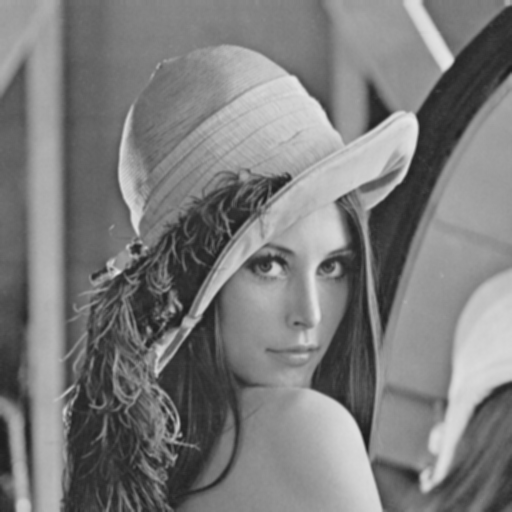

In [81]:
filter1 = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 1/9, 1/9 ],
    [1/9, 1/9, 1/9]
])

img1 = np.uint8(cv.filter2D(gray, -1, filter1))

cv2_imshow(img1)

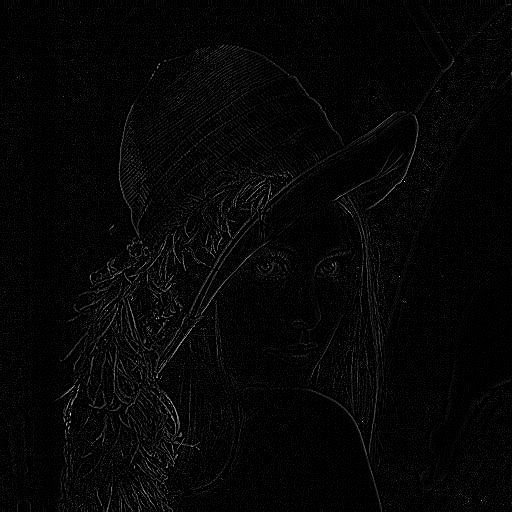

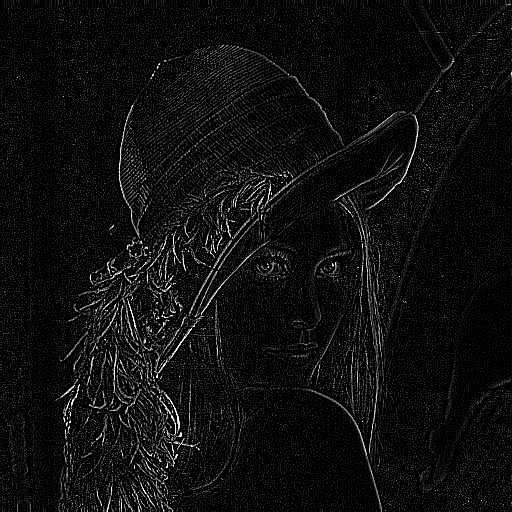

In [82]:
filter2 = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
])
filter3 = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

img2 = np.uint8(cv.filter2D(gray, -1, filter2))
img3 = np.uint8(cv.filter2D(gray, -1, filter3))

cv2_imshow(img2)
cv2_imshow(img3)

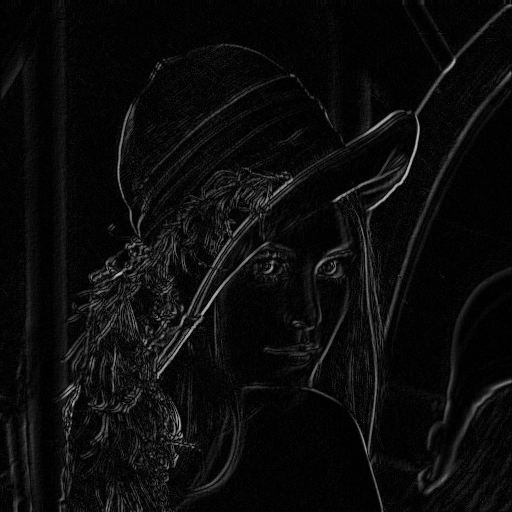

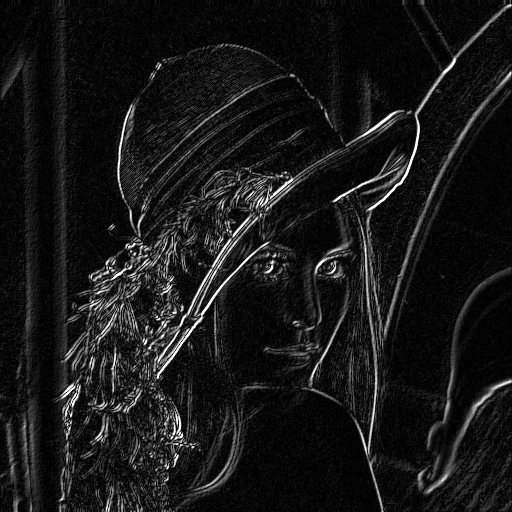

In [83]:
filter4 = np.array([
    [-1, 0, 0],
    [0, 0, 0],
    [0, 0, 1]
], dtype=np.float32)

filter5 = np.array([
    [-1, -1, 0],
    [-1,  0,  1],
    [ 0,  1,  1]
], dtype=np.float32)

img4 = cv.filter2D(gray, cv.CV_32F, filter4)
img5 = cv.filter2D(gray, cv.CV_32F, filter5)

img4 = cv.convertScaleAbs(img4)
img5 = cv.convertScaleAbs(img5)

cv2_imshow(img4)
cv2_imshow(img5)

**결과분석**

가우시안 블러, 박스 필터를 이용했을 때는 기존 이미지에서 블러된 이미지를 얻게 되었다.

중앙이 4인 filter1를 적용한 경우 상하의 엣지만 검출되기 때문에 중앙이 8인 filter2에 비해 경계가 선명하지 않은 것을 알 수 있었다. 중앙이 8인 filter2의 경우 대각성분까지 함께 검출하기 때문에 엣지가 더 정확한 것을 알 수 있다.

마지막 좌 상단, 우 하단 경계만 검출하는 filter3보다 filter4은 더 넓게 검출하기 때문에 더 뚜렷한 경계를 가지는 것을 확인하였다.

HW#2-4

아래와 같은 영상에 대하여 45°, -45° 방향의 대각선 edge를 검출하되, Sobel 연산자를 변형하여 적절한 마스크를 만들어 적용해보세요.

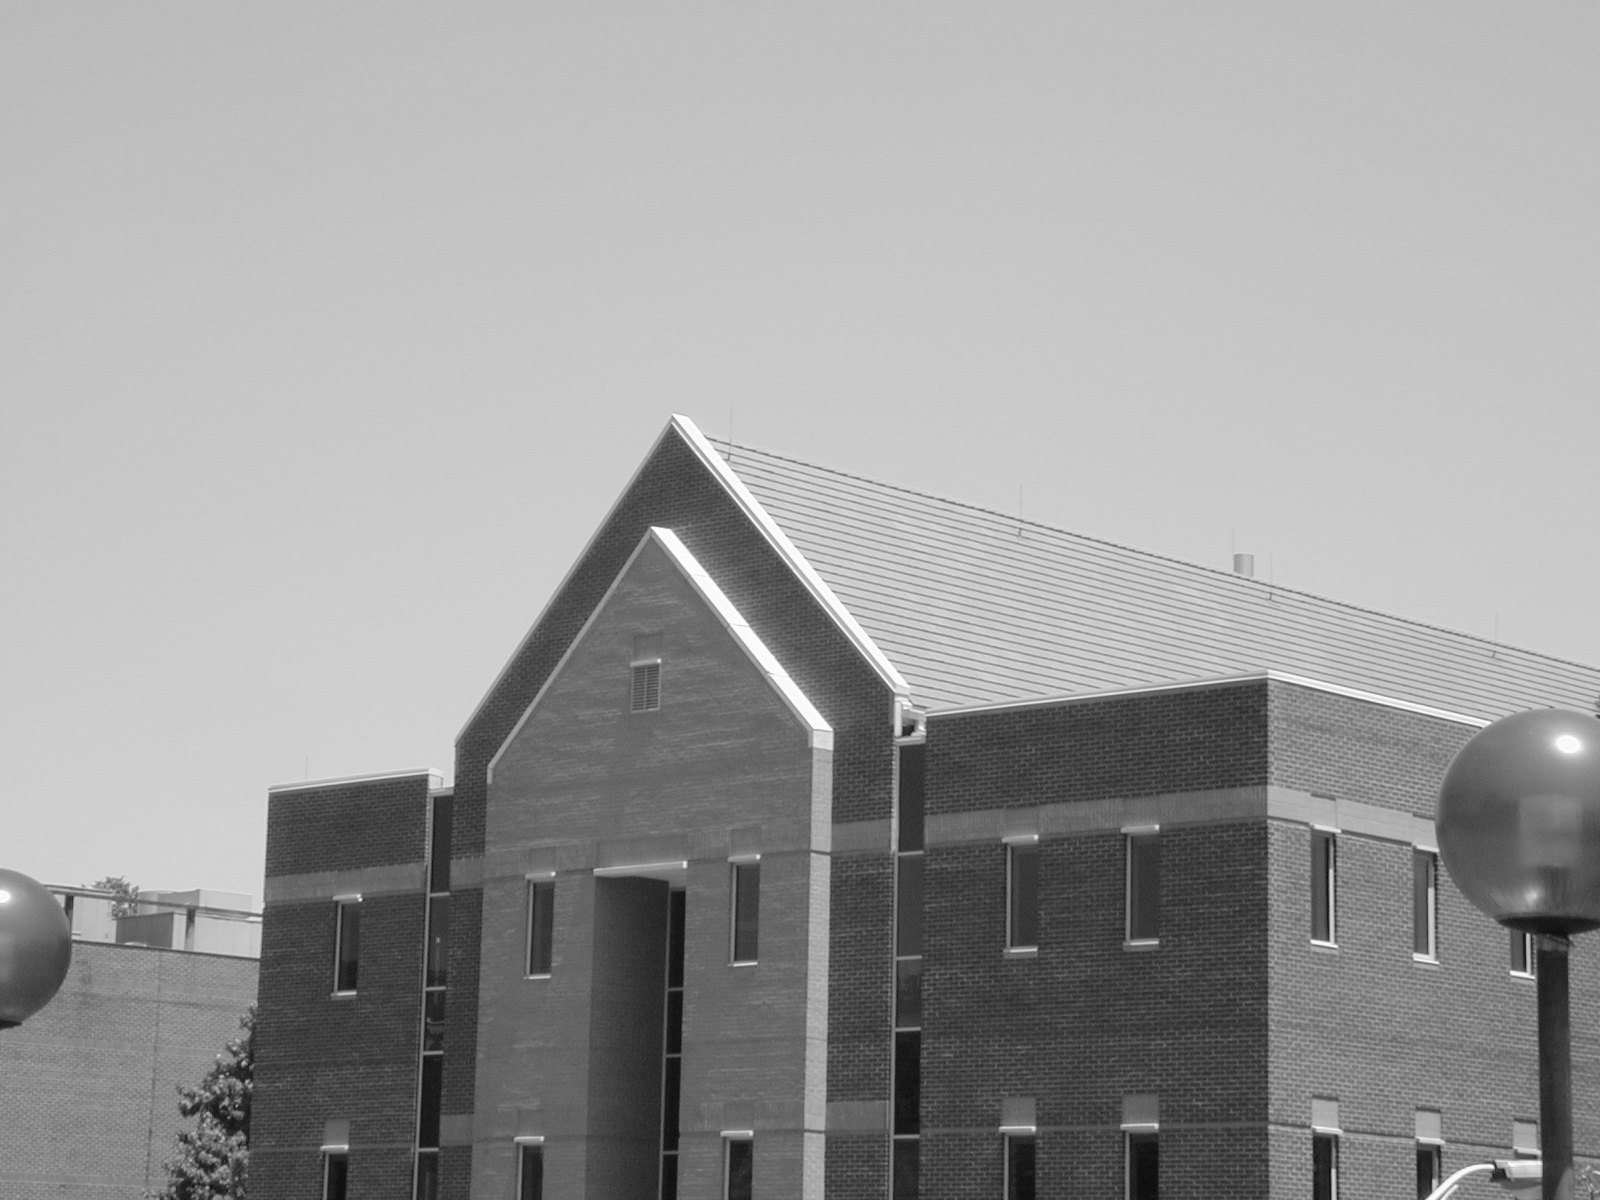

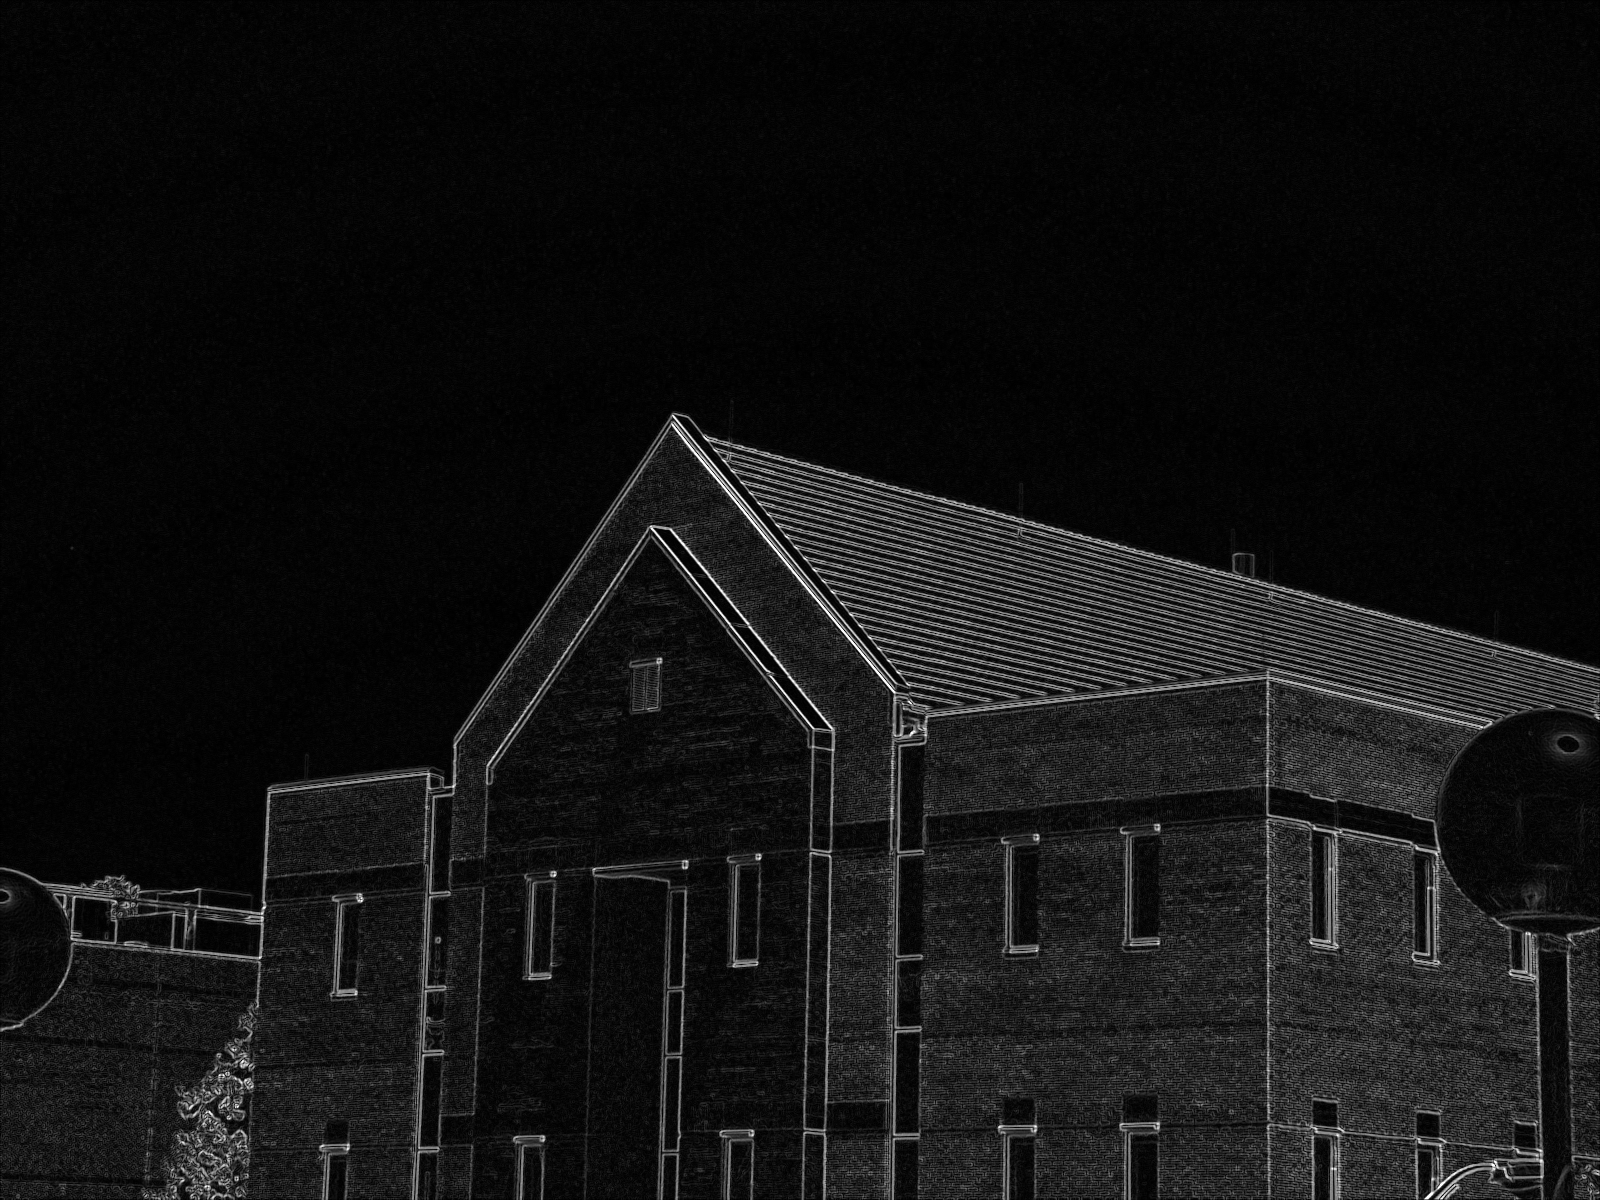

In [84]:
img = cv.imread('/content/sample_data/school.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

grad_x = cv.Sobel(gray, cv.CV_32F,1,0,ksize=3)
grad_y = cv.Sobel(gray, cv.CV_32F,0,1,ksize=3)

sobel_x = cv.convertScaleAbs(grad_x)
sobel_y = cv.convertScaleAbs(grad_y)

edge_strength = cv.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)

cv2_imshow(gray)
cv2_imshow(edge_strength)

HW#2-5

왼쪽의 지문영상을 오른쪽 영상과 같이 개선해보세요. 수업시간에 배운 방법을 기본적으로 적용해보고, 더 좋은 방법이 있으면 해당 방법도 적용하고 결과를 분석해보세요.

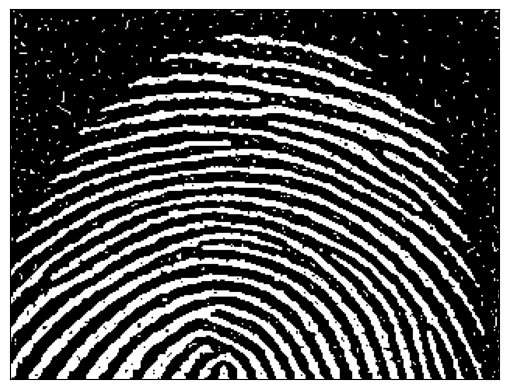

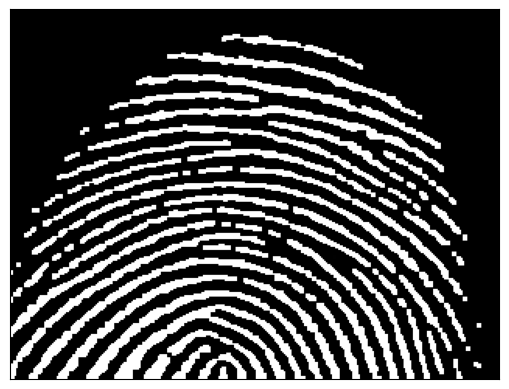

In [85]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('/content/sample_data/finger.jpg', cv.IMREAD_UNCHANGED)

plt.imshow(img, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

se = np.uint8([
    [1,1,1],
    [1,1,1],
    [1,1,1]
])

img_erosion = cv.erode(img, se, iterations=1)
img_dilation = cv.dilate(img_erosion, se, iterations=1)
img_closing = cv.erode(cv.dilate(img_dilation, se, iterations=1), se, iterations=1)
plt.imshow(img_closing, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

**결과분석**

다음과 같은 방법을 적용하였다.
1) erosion을 이용해 흰색 노이즈를 제거한다
2) dilation을 이용해 노이즈를 줄이고 지문 영역을 확보한다.
3) closing을 통해 지문 영역을 검출한 이미지 결과를 얻는다.

HW#2-6

다음 영상에서 원하는 선분을 없애 보시고,
어떻게 했는지 분석하세요.

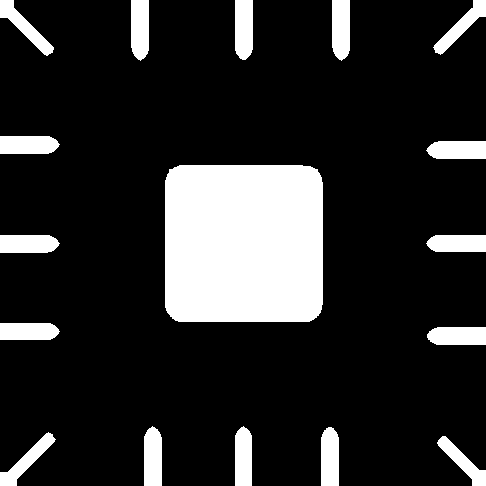

In [86]:
img = cv.imread('/content/sample_data/Fig0905(a)(wirebond-mask).tif', cv.IMREAD_UNCHANGED)

se = np.uint8(
    [[1 for _ in range(14)] for _ in range(14)] # 13 x 13 생성
)
img_erosion = cv.erode(img, se, iterations=1)

cv2_imshow(img_erosion)

**결과분석**

모든 선분을 지우고 싶어서 13x13짜리 se를 사용하여 erosion을 해서 네모로 향하는 모든 선분이 사라졌다.

HW#2-7

아래의 Edge 검출 알고리즘 사용하여 edge를 검출하고, 각각 결과가 어떻게 다른 지 비교하세요.

▪ Sobel
▪ Laplacian
▪ Canny
▪ Morphological Gradient

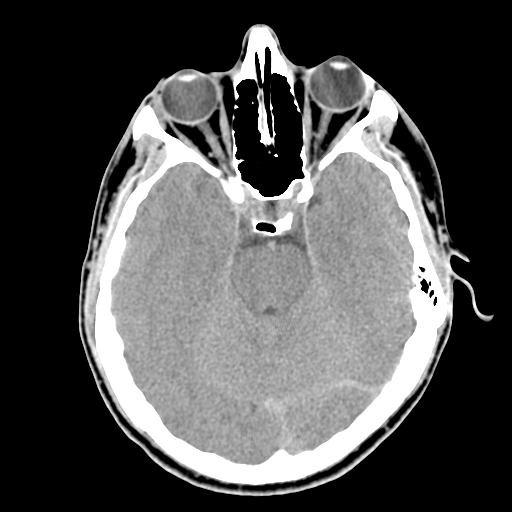

In [87]:
img=cv.imread('/content/sample_data/Fig0939(a)(headCT-Vandy).tif', cv.IMREAD_UNCHANGED)
cv2_imshow(img)

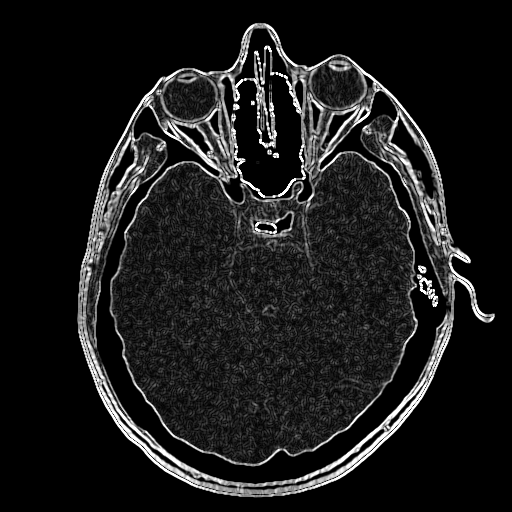

In [88]:
# sobel
grad_x = cv.Sobel(img, cv.CV_32F,1,0,ksize=3)
grad_y = cv.Sobel(img, cv.CV_32F,0,1,ksize=3)

sobel_x = cv.convertScaleAbs(grad_x)
sobel_y = cv.convertScaleAbs(grad_y)

edge_strength = cv.addWeighted(sobel_x, 0.5, sobel_y, 0.5, 0)
cv2_imshow(edge_strength)

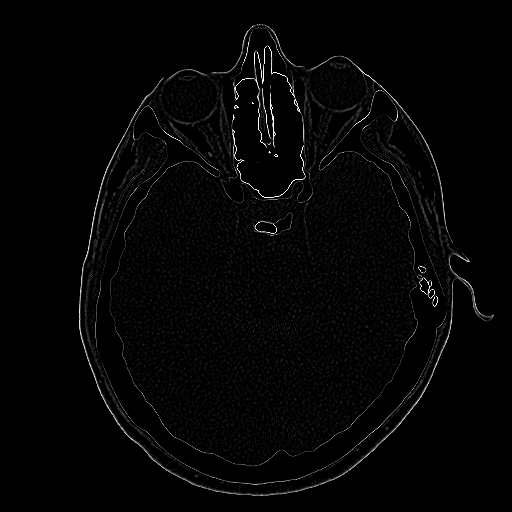

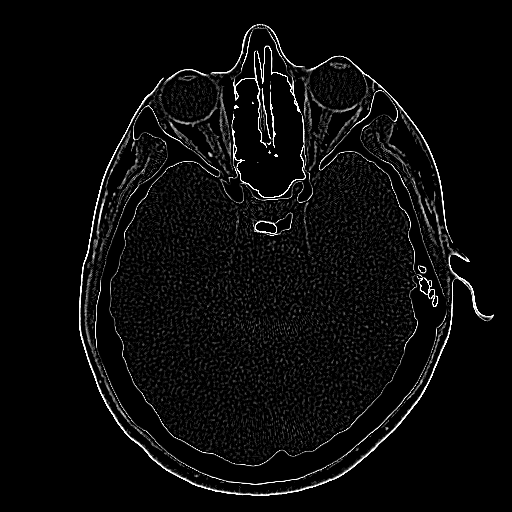

In [89]:
# Laplasian
img1 = cv.Laplacian(img, cv.CV_32F)

filter_2 = np.array([
    [0, -1, 0],
    [-1, 4, -1],
    [0, -1, 0]
])
filter_3 = np.array([
    [-1, -1, -1],
    [-1, 8, -1],
    [-1, -1, -1]
])

img_2 = np.uint8(cv.filter2D(img, -1, filter_2))
img_3 = np.uint8(cv.filter2D(img, -1, filter_3))

cv2_imshow(img_2)
cv2_imshow(img_3)

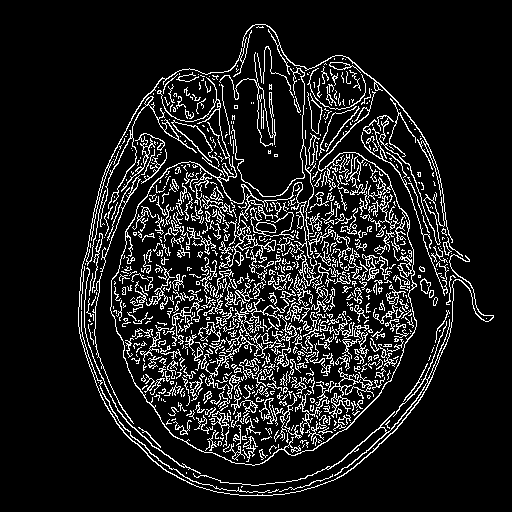

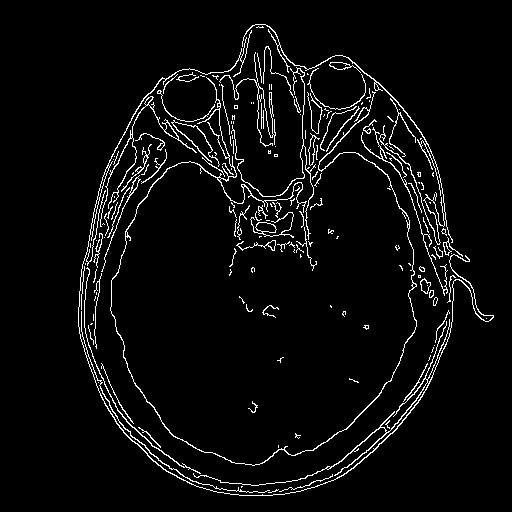

In [90]:
# Canny
canny1 = cv.Canny(img, 50, 100)
canny2 = cv.Canny(img, 100, 200)
cv2_imshow(canny1)
cv2_imshow(canny2)

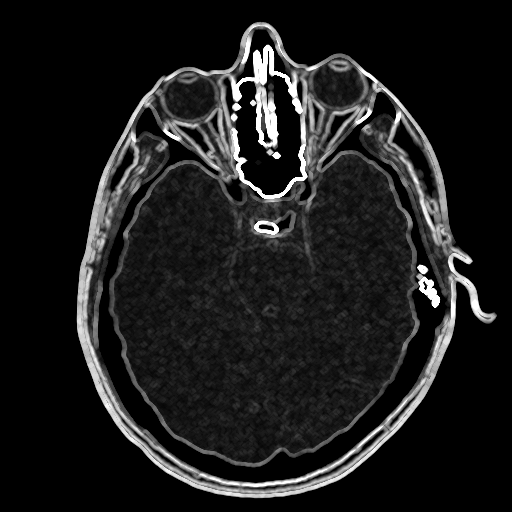

In [91]:
# Mophological Gradient
se = np.uint8([
    [0,0,1,1,0,0],
    [0,1,1,1,1,0],
    [1,1,1,1,1,1],
    [0,1,1,1,1,0],
    [0,0,1,1,0,0]
])

img_dilation = cv.dilate(img , se, iterations=1)
img_erosion = cv.erode(img, se, iterations=1)

img_edge = img_dilation - img_erosion
cv2_imshow(img_edge)

**결과분석**


**Sobel**

x축, y축 방향의 1차 미분값을 계산하여 이미지의 경계를 검출하는 방식이며, 엣지가 뚜렷하게 검출되는 것을 확인하였다.

**Laplacian**
  
x축, y축만 검출하는 것이 아니라 대각 방향까지 검출되어 엣지가 더 뚜렷하게 검출되는 것을 확인하였다.

**Canny**

옵션값을 (50,100)으로 줬을때는 불필요한 edge까지 검출되고 (100, 200)으로 할 경우 불필요한 edge가 많이 사라졌다.

**Morphological Gradient**

경계가 애매하게 느껴지긴 했지만 어느정도 엣지가 생성된 것을 확인할 수 있었다.

HW#2-8

아래의 알고리즘을 사용하여 노이즈라 생각되는 영역을 지우고, 각각 결과가 어떻게 다른 지 비교 분석하세요.

▪ Morphological Smoothing
▪ Smoothing Filter

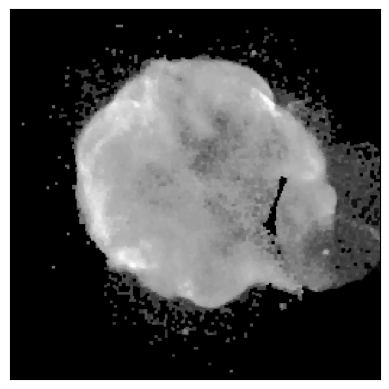

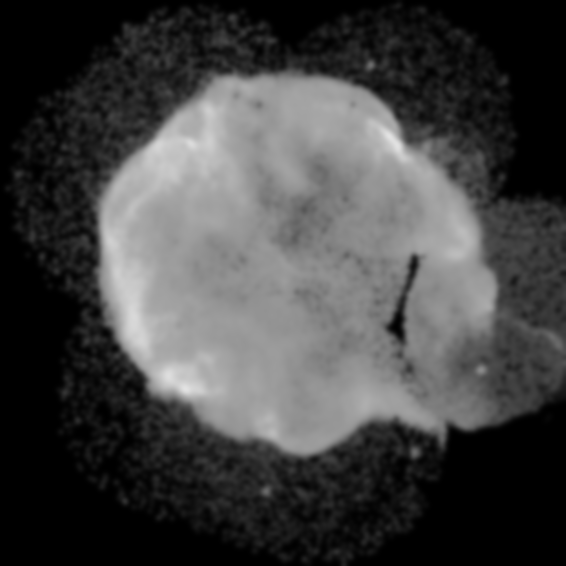

In [92]:
img=cv.imread('/content/sample_data/Fig0938(a)(cygnusloop_Xray_original).tif',cv.IMREAD_UNCHANGED)

se = np.uint8([
    [1,1,1,1],
    [1,1,1,1],
    [1,1,1,1],
    [1,1,1,1]
])

# mophological smoothing
img_opening = cv.dilate(cv.erode(img, se, iterations=1), se, iterations=1)
img_closing = cv.erode(cv.dilate(img_opening, se, iterations=1), se, iterations=1)
plt.imshow(img_closing, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

# smoothing filter
cv2_imshow(cv.GaussianBlur(img,(15,15),0.0))

**결과분석**

1) Morphological Smoothing의 경우 Lecture2 파일의 12번처럼 dilate와 erode를 통해 노이즈로 보일 수 있는 부분을 제거했다.

2) 가우시안 블러를 통해 노이즈로 인식할만한 영역을 줄였다.

HW#2-9

다음 영상을 이진화하되, 수업시간에 배운 2가지 방법을 모두 써보고, 각각의 결과에 대해 비교 분석하세요.

In [103]:
img=cv.imread('/content/sample_data/Fig0940(a)(rice_image_with_intensity_gradient).tif',cv.IMREAD_UNCHANGED)

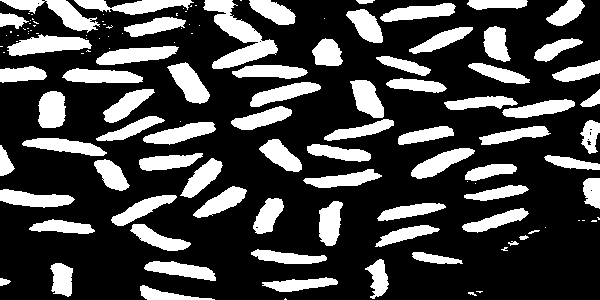

In [104]:
def disk_se(radius):
    size = 2 * radius + 1
    se = np.zeros((size, size), dtype="uint8")
    cy, cx = radius, radius

    for y in range(size):
        for x in range(size):
            if (y - cy) ** 2 + (x - cx) ** 2 <= radius ** 2:
                se[y, x] = 1

    return se

t, bin_img = cv.threshold(img[::2],0, 255, cv.THRESH_BINARY+cv.THRESH_OTSU)
cv2_imshow(bin_img)

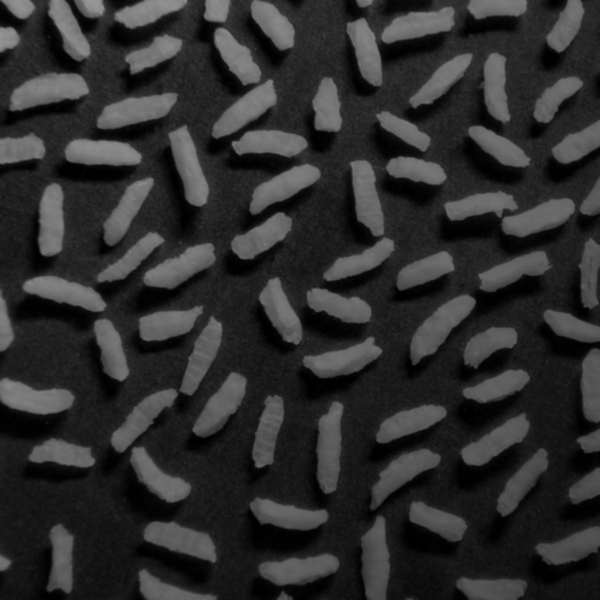

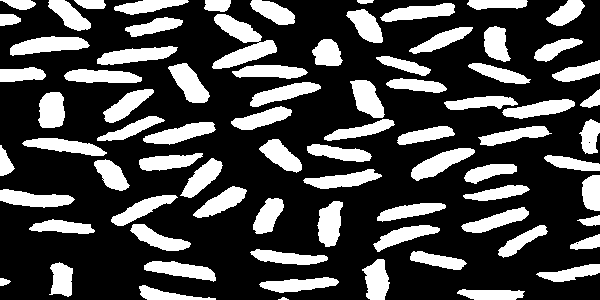

In [102]:
se_opening = disk_se(60)
img_opening = cv.dilate(cv.erode(img, se_opening, iterations = 1), se_opening, iterations = 1)
img_tophat = img - img_opening

cv2_imshow(img_tophat)

t, bin_img = cv.threshold(img_tophat[::2],0, 255, cv.THRESH_BINARY+cv.THRESH_OTSU)
cv2_imshow(bin_img)

**결과분석**

1) 첫번째 결과와 같이 그냥 이진화를 할 경우 우하단 쌀처럼 누락되는 것이 있다.
2) tophat transformation를 통해 배경의 영향을 제거한 후 이진화할 경우, 배경의 영향력이 줄어들어 이전에 누락된 쌀도 잘 이진화되는 것을 확인할 수 있었다.

HW#2-10

다음 영상을 Morphology를 적용하여 오른쪽과 같이 분할하세요.

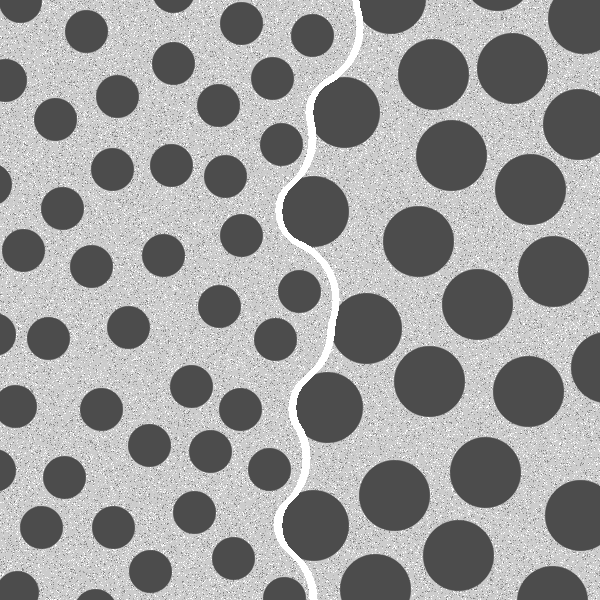

In [112]:
def disk_se(radius):
    size = 2 * radius + 1
    se = np.zeros((size, size), dtype=np.uint8)
    cy, cx = radius, radius

    for y in range(size):
        for x in range(size):
            if (y - cy) ** 2 + (x - cx) ** 2 <= radius ** 2:
                se[y, x] = 1

    return se

img=cv.imread('/content/sample_data/Fig0943(a)(dark_blobs_on_light_background).tif', cv.IMREAD_UNCHANGED)

se_closing = disk_se(30)
se_opening = disk_se(60)

img_closing = cv.erode(cv.dilate(img, se_closing, iterations=1), se_closing, iterations=1)
img_opening = cv.dilate(cv.erode(img_closing, se_opening, iterations=1), se_opening, iterations=1)

se = np.uint8([
    [0,0,1,1,0,0],
    [0,1,1,1,1,0],
    [1,1,1,1,1,1],
    [0,1,1,1,1,0],
    [0,0,1,1,0,0]
])

mophological_gradient = cv.dilate(img_opening, se, iterations=1)  - cv.erode(img_opening, se, iterations=1)

overlay = img.copy()
overlay[mophological_gradient > 0] = 255

cv2_imshow(overlay)